# House Price Analysis & Prediction
This project aims to analyze housing data and build a regression model to predict house prices.


In [36]:
#step1:import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [37]:
#step2:import dataset
house_price=pd.read_csv('https://github.com/YBIFoundation/Dataset/raw/main/Boston.csv')

## Dataset Overview
The dataset contains various socio-economic and housing features used to predict median house value (MEDV).


In [38]:
house_price.head()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [39]:
house_price.describe()

,CRIM,ZN,INDUS,CHAS,NX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [40]:
house_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NX       506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [41]:
house_price.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

## Exploratory Data Analysis
We analyze feature relationships and distribution patterns to understand key drivers of house prices.


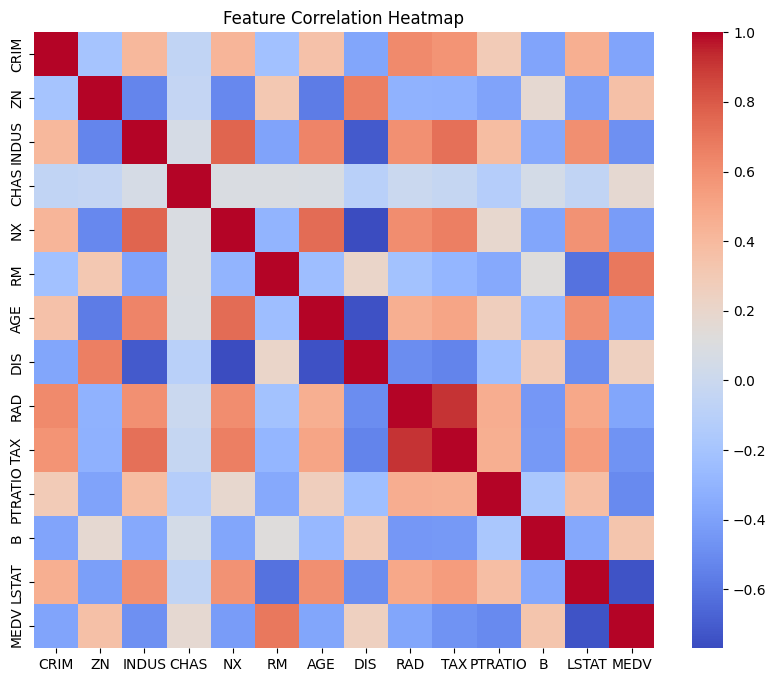

In [42]:
plt.figure(figsize=(10,8))
sns.heatmap(house_price.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


The heatmap revealed strong correlation between RAD and TAX, indicating potential multicollinearity. After removing one of the features, the R² score decreased from 0.65 to 0.61, showing that both variables contribute meaningful predictive information. Therefore, both features were retained in the final model.

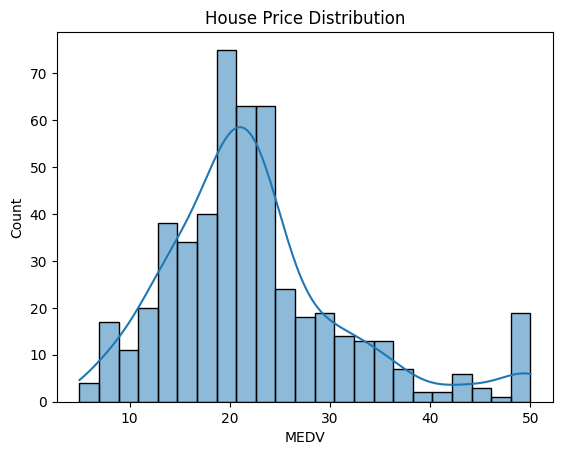

In [43]:
sns.histplot(house_price['MEDV'], kde=True)
plt.title("House Price Distribution")
plt.show()


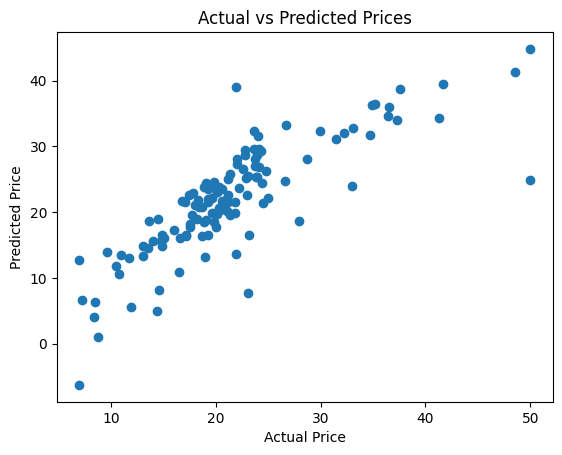

In [44]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [45]:
#step3: select y and x
y=house_price['MEDV']
X=house_price[['CRIM', 'ZN', 'INDUS', 'CHAS', 'NX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']]

In [46]:
#step4:train test and split
from sklearn.model_selection import train_test_split

In [47]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=2529)

In [48]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((379, 13), (127, 13), (379,), (127,))

In [49]:
#step5:select model
from sklearn.linear_model import LinearRegression
model=LinearRegression()


## Model Building
We use Linear Regression to model the relationship between housing features and price.


In [50]:
#step 6: train model
model.fit(X_train,y_train)

LinearRegression()

In [51]:
model.intercept_

np.float64(31.25533453751924)

In [52]:
model.coef_

array([-1.27113473e-01,  3.42913377e-02,  2.60868350e-03,  2.38959719e+00,
       -1.82552392e+01,  4.48454125e+00,  1.61769130e-03, -1.46612188e+00,
        2.40205715e-01, -9.08110896e-03, -9.17943140e-01,  1.03133823e-02,
       -5.29465536e-01])

In [53]:
pd.Series(model.coef_, index=X.columns)

,0
CRIM,-0.127113
ZN,0.034291
INDUS,0.002609
CHAS,2.389597
NX,-18.255239
RM,4.484541
AGE,0.001618
DIS,-1.466122
RAD,0.240206
TAX,-0.009081


In [54]:
#step7:prediction
y_pred=model.predict(X_test)

In [55]:
y_test

,MEDV
229,31.5
45,19.3
119,19.3
232,41.7
461,17.7
...,...
320,23.8
364,21.9
309,20.3
84,23.9


## Model Evaluation
Model performance is evaluated using Mean Absolute Percentage Error (MAPE) and R² score.


In [56]:
#step8:evaluate
from sklearn.metrics import mean_absolute_percentage_error,r2_score
mean_absolute_percentage_error(y_test,y_pred)

0.1702803409644982

In [57]:
r2_score(y_test,y_pred)

0.6514645412749412

## Key Findings
- Number of rooms significantly increases house value.
- Higher pollution levels reduce property prices.
- Socio-economic indicators strongly influence housing market trends.